In [36]:
import warnings
warnings.filterwarnings('ignore')

In [37]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from talib import RSI, BBANDS, MACD

In [38]:
sns.set_style('whitegrid')
idx = pd.IndexSlice

In [39]:
path = os.path.join("..", "..", "data", "assets.h5")

with pd.HDFStore(path) as store:
    data = (
        store['prices/chile']
        .loc[ "2020" : "2025" , "COPEC.SN"]
    )

In [40]:
data.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 1561 entries, 2020-01-01 to 2025-12-29
Series name: COPEC.SN
Non-Null Count  Dtype  
--------------  -----  
1561 non-null   float64
dtypes: float64(1)
memory usage: 24.4 KB


# Rolling Bands

In [41]:
up, mid, low = BBANDS(data, timeperiod=21, nbdevup = 2, nbdevdn = 2, matype= 0)

# Compute relative strength index 

In [42]:
rsi = RSI(data, timeperiod = 14)

# Moving average convergence / divergence (MACD)

The MACD computes the difference between two Exponential Moving Averages (EMA), one longer- and one shorter-term.

The ta-lib MACD Indicator implementation has four inputs:

- the close price
- fastperiod: the short-term EMA period
- slowperiod: the long-term EMA period
- signalperiod: the period for the EMA of the MACD itself

It has three outputs:

- macd is the difference between the fast EMA and slow EMA.
- macdsignal is the EMA of the MACD value with period signalperiod
- macdhist computes the difference between macd and macdsignal

In [43]:
macd, macdsignal, macdhist = MACD(data, fastperiod=12, slowperiod=26, signalperiod=9)

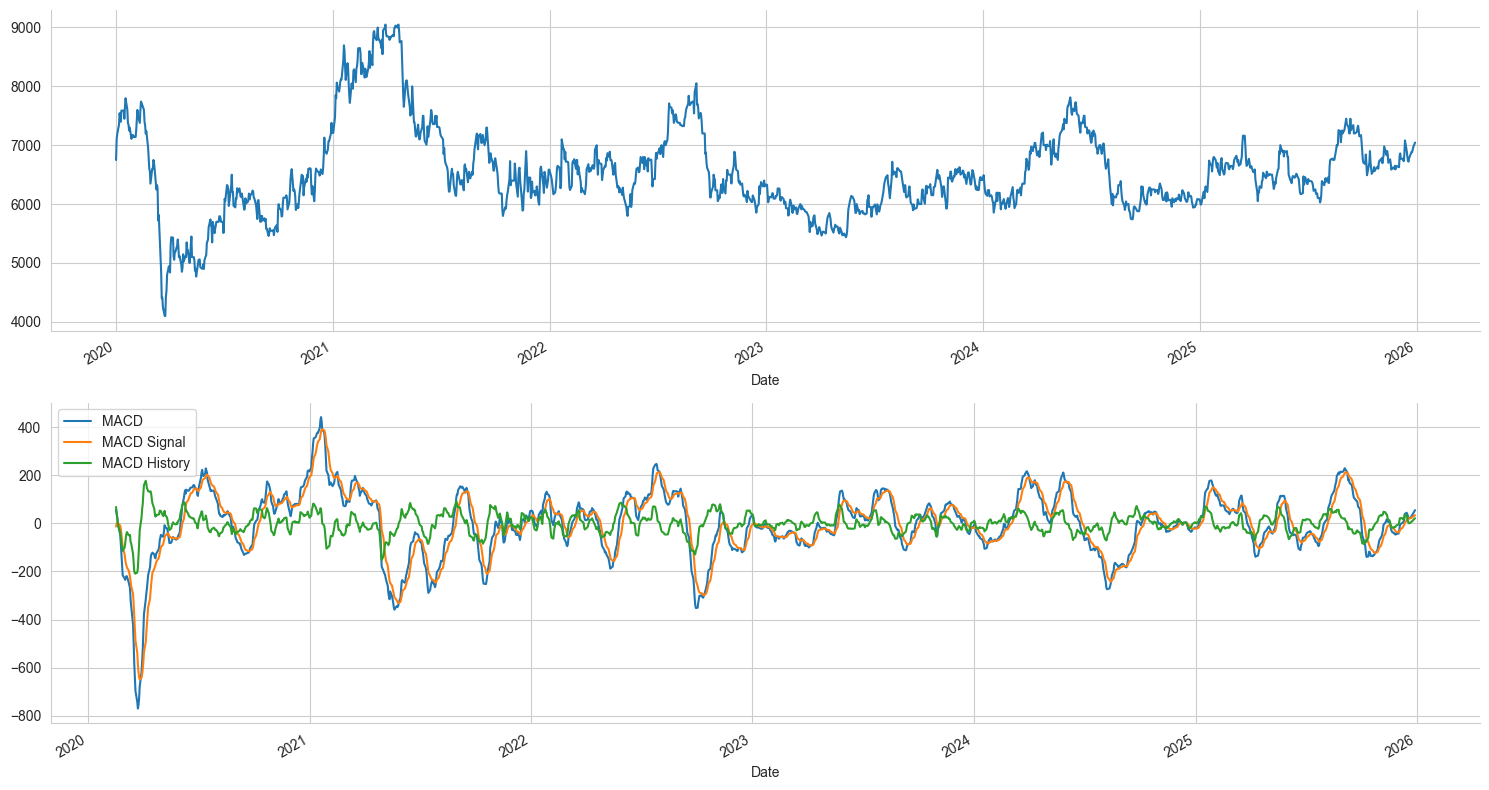

In [44]:
macd_data = pd.DataFrame({'AAPL': data, 'MACD': macd, 'MACD Signal': macdsignal, 'MACD History': macdhist})

fig, axes= plt.subplots(nrows=2, figsize=(15, 8))
macd_data.AAPL.plot(ax=axes[0])
macd_data.drop('AAPL', axis=1).plot(ax=axes[1])
fig.tight_layout()
sns.despine()

# Plot result

In [45]:
data = pd.DataFrame({'COPEC.SN': data, 'BB Up': up, 'BB Mid': mid, 'BB down': low, 'RSI': rsi, 'MACD': macd})

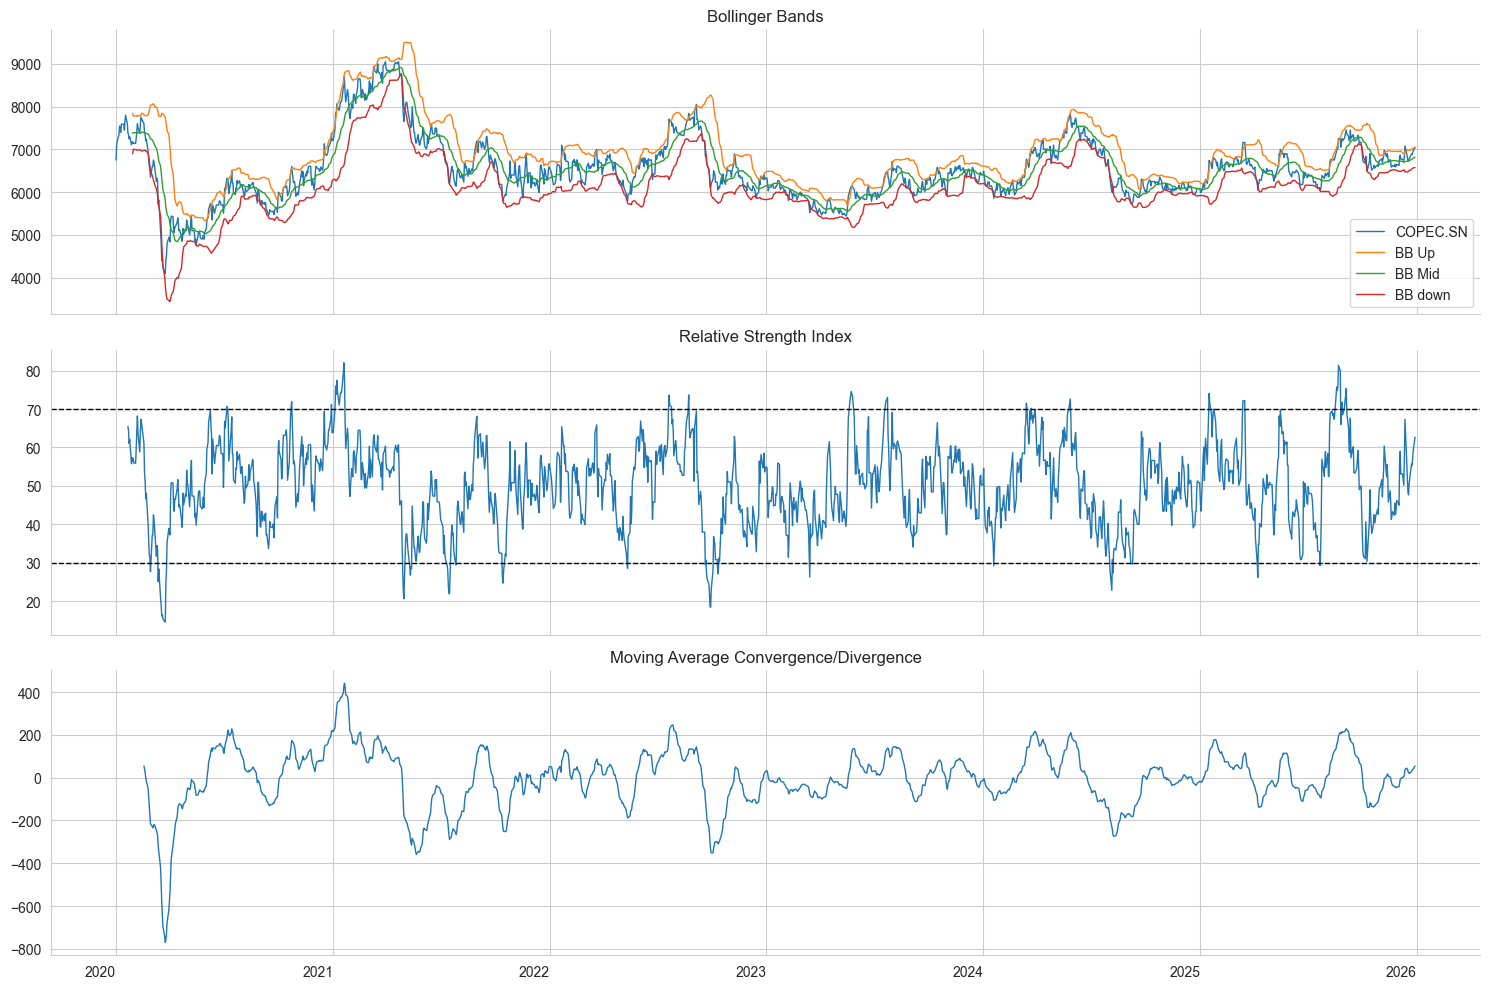

In [46]:
fig, axes= plt.subplots(nrows=3, figsize=(15, 10), sharex=True)
data.drop(['RSI', 'MACD'], axis=1).plot(ax=axes[0], lw=1, title='Bollinger Bands')
data['RSI'].plot(ax=axes[1], lw=1, title='Relative Strength Index')
axes[1].axhline(70, lw=1, ls='--', c='k')
axes[1].axhline(30, lw=1, ls='--', c='k')
data.MACD.plot(ax=axes[2], lw=1, title='Moving Average Convergence/Divergence', rot=0)
axes[2].set_xlabel('')
fig.tight_layout()
sns.despine();